In [2]:
#import relevant libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from collections import defaultdict
import dabest
import NLCLIMB
import NLMATH
import matplotlib.patches as mpatches
from matplotlib.collections import PolyCollection

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
# File processing
workcomp = "C:\\Users\\User"
laptop = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
specifiedpath = workcomp

filepath = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Together\\3. Compiled\\"
openPath = specifiedpath + filepath
files2 = os.listdir(openPath)

## Functions

In [8]:
def darken_color(hex_color, factor=0.6):
    hex_color = hex_color.lstrip('#')
    rgb = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4))
    darkened_rgb = tuple(max(0, min(1, c * factor)) for c in rgb)
    return '#{:02x}{:02x}{:02x}'.format(
        int(darkened_rgb[0] * 255),
        int(darkened_rgb[1] * 255),
        int(darkened_rgb[2] * 255)
    )


def calculate_grouped_positions(matched_crosses, within_spacing=1.2, between_spacing=0.8):
    driver_groups = defaultdict(list)
    for i, item in enumerate(matched_crosses):
        base_cross = item[-1] if isinstance(item, tuple) else item
        driver = base_cross.split(' x ')[0]
        driver_groups[driver].append(i)
    
    cell_width = within_spacing  # equal to spacing so boxes sit edge-to-edge
    
    positions = []
    current_position = 0
    sorted_drivers = sorted(driver_groups.keys(), key=lambda d: min(driver_groups[d]))
    
    for driver_idx, driver in enumerate(sorted_drivers):
        for idx in driver_groups[driver]:
            positions.append(current_position)
            current_position += within_spacing
        if driver_idx < len(sorted_drivers) - 1:
            current_position += between_spacing
    
    # Reorder to match original order
    position_mapping = {}
    counter = 0
    for driver in sorted_drivers:
        for idx in driver_groups[driver]:
            position_mapping[idx] = positions[counter]
            counter += 1
    
    final_positions = [position_mapping[i] for i in range(len(matched_crosses))]
    final_cell_widths = [cell_width] * len(matched_crosses)
    return final_positions, driver_groups, final_cell_widths

def parse_responders_with_atr(matched_crosses):
    drivers, responders_base, has_atr = [], [], []
    
    for item in matched_crosses:
        base_cross = item[-1] if isinstance(item, tuple) else item
        parts = base_cross.split(' x ')
        if len(parts) >= 2:
            drivers.append(parts[0])
            responder_full = parts[1].strip()
            if ' allstats' in responder_full:
                responder_full = responder_full.split(' allstats')[0].strip()
            
            if '[ATR]' in responder_full:
                responders_base.append(responder_full.replace('[ATR]', '').strip())
                has_atr.append(True)
            else:
                responders_base.append(responder_full)
                has_atr.append(False)
    
    # Build unique responders list (preserve order)
    unique_responders = list(dict.fromkeys(responders_base))
    if any(has_atr):
        unique_responders.append('ATR')
    
    return drivers, responders_base, has_atr, unique_responders

def draw_table_grid(ax, positions, row_y_positions, cell_widths, cell_height, total_rows):
    import matplotlib.patches as patches
    for i, center_pos in enumerate(positions):
        cw = cell_widths[i] if isinstance(cell_widths, list) else cell_widths
        for row_idx in range(total_rows):
            rect = patches.Rectangle(
                (center_pos - cw/2, row_y_positions[row_idx]),
                cw, cell_height,
                linewidth=1, edgecolor='black', facecolor='white'
            )
            ax.add_patch(rect)

def place_table_dots_and_n(ax, positions, matched_crosses, responders_base, has_atr, 
                           unique_responders, row_y_positions, cell_height, 
                           singlemeandiff, markersize, fontsize):
    total_rows = len(row_y_positions)
    
    for i, center_pos in enumerate(positions):
        # Place responder dot
        base_responder = responders_base[i]
        if base_responder in unique_responders:
            row_idx = unique_responders.index(base_responder)
            y_center = row_y_positions[row_idx] + (cell_height * 0.5)
            ax.plot(center_pos, y_center, 'ko', markersize=markersize)
        
        # Place ATR dot if applicable
        if has_atr[i] and 'ATR' in unique_responders:
            atr_row_idx = unique_responders.index('ATR')
            y_center_atr = row_y_positions[atr_row_idx] + (cell_height * 0.5)
            ax.plot(center_pos, y_center_atr, 'ko', markersize=markersize)
        
        # Sample size in N's row (shifted slightly down from center)
        cross_full = matched_crosses[i][0]
        sample_size = singlemeandiff[singlemeandiff['cross'] == cross_full]['samplesize'].iloc[0]
        n_row_y = row_y_positions[total_rows - 1] + (cell_height * 0.35)
        ax.text(center_pos, n_row_y, str(sample_size), ha='center', va='center', 
                fontsize=fontsize)

def add_table_labels(ax, positions, unique_responders, row_y_positions, cell_height,
                     driver_groups, cell_widths, fontsize_table, fontsize_driver):
    total_rows = len(row_y_positions)
    max_cw = max(cell_widths) if isinstance(cell_widths, list) else cell_widths
    label_x = min(positions) - max_cw * 0.6
    
    # Responder row labels
    for row_idx, responder in enumerate(unique_responders):
        y_center = row_y_positions[row_idx] + (cell_height * 0.5)
        ax.text(label_x, y_center, responder, ha='right', va='center', 
                fontsize=fontsize_table)
    
    # N's row label
    n_row_y = row_y_positions[total_rows - 1] + (cell_height * 0.5)
    ax.text(label_x, n_row_y, "N's", ha='right', va='center', 
            fontsize=fontsize_table)
    
    # Driver labels with grouping lines
    for driver, indices in driver_groups.items():
        if indices:
            x_positions = [positions[i] for i in indices]
            widths = [cell_widths[i] if isinstance(cell_widths, list) else cell_widths for i in indices]
            x_start = min(x_positions) - widths[0] / 2
            x_end = max(x_positions) + widths[-1] / 2
            y_pos = row_y_positions[total_rows - 1] - (cell_height * 0.25)
            
            ax.plot([x_start, x_end], [y_pos, y_pos], 'k-', linewidth=1)
            ax.text(np.mean(x_positions), y_pos - (cell_height * 0.25), driver, 
                    ha='center', va='top', fontsize=fontsize_driver, style='italic')

def format_main_axes(ax, positions, ylim, fontsize_tick):
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.set_ylim(ylim)
    y_min, y_max = ylim
    ax.set_yticks(np.arange(np.ceil(y_min), np.floor(y_max) + 1, 1))
    ax.tick_params(axis='y', labelsize=fontsize_tick)
    if positions:
        ax.set_xlim(min(positions) - 1.0, max(positions) + 1.0)
    ax.grid(False)
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)
    ax.set_xticks([])

def cleanup_table_axes(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

def pergenotypeplotting(openPath, files2, k, effect_type='hedgesg'):
    metricname = pd.DataFrame()
    singlemeandiff = pd.DataFrame()

    effect_col = k + "_Hedgesg" if effect_type == 'hedgesg' else k + "_deltag"
    effect_label = 'Hedgesg' if effect_type == 'hedgesg' else 'deltag'

    for f in files2:
        newfile2read = pd.read_csv(openPath + f, index_col=0)
        cross = (f.replace("_wtcomparison.csv", "")
                 .replace(" allstats.csv", "")
                  .replace("eOPN3", "OPN3")
                  .replace("[B]", "")
                  .replace("(iii)M4", ""))

        samplefile = pd.DataFrame({
            'bootstrap': newfile2read[k+"_bootstrap"],
            effect_label: newfile2read[effect_col],
            'Cross': cross,
            'metric': k,
            'samplesize': newfile2read['Sample_size']
        })

        singlemeans = pd.DataFrame({
            'mean': samplefile[effect_label].unique(),
            'cross': cross,
            'samplesize': newfile2read['Sample_size'].unique(),
            'err': samplefile['bootstrap'].mean() - (samplefile['bootstrap'].mean() - 1.96*(np.std(samplefile['bootstrap'])))
        })

        metricname = pd.concat([metricname, samplefile], axis=0)
        singlemeandiff = pd.concat([singlemeandiff, singlemeans], axis=0)

    return metricname, singlemeandiff

# Backward-compatible wrapper functions
def pergenotypeplotting_deltag(openPath, files2, k):
    return pergenotypeplotting(openPath, files2, k, effect_type='deltag')

def pergenotypeplotting_hedgesg(openPath, files2, k):
    return pergenotypeplotting(openPath, files2, k, effect_type='hedgesg')

def get_responder_color(cross_name):
    
    cross_lower = cross_name.lower()
    if 'acr' in cross_lower or 'gtacr' in cross_lower:
        color = "#1AB80B"
        noatrcolor= "#7FC801FF"
    elif 'ts-er' in cross_lower:
        color = "#8B5A2B"
        noatrcolor = "#8B5A2B"
    elif 'opn3' in cross_lower or 'eopn3' in cross_lower:
        color = "#07527A"
        noatrcolor= "#19BBDFFF"
    else:
        color = "#9452FF"
        noatrcolor = "#B07EFF"
        
    
    has_atr = '[ATR]' in cross_name or '[atr]' in cross_name
    return color, noatrcolor, has_atr

def forestplot_single_phase_table(metricname_full, singlemeandiff_full, gridkey1=None, gridkey2=None, 
                                  figsize=(10, 8), ylim=(-4.0, 0), 
                                  ratio=[0.7, 0.3], hspace=0,
                                  ylabel_fontsize=None, ytick_fontsize=None, xlabel_fontsize=None,
                                  gridkey_fontsize=None, gridkey_ylabel_fontsize=None, markersize=None):
    
    # Validate ratio
    if len(ratio) != 2 or sum(ratio) + hspace > 1.0 or any(r <= 0 for r in ratio) or hspace < 0:
        raise ValueError("Invalid ratio/hspace parameters")

    # Scaling
    scale_factor = ((figsize[0] / 10) + (figsize[1] / 8)) / 2
    ratio_scale = ratio[1] / 0.3
    ylabel_fontsize = ylabel_fontsize or int(14 * scale_factor)
    ytick_fontsize = ytick_fontsize or int(12 * scale_factor)
    xlabel_fontsize = xlabel_fontsize or int(10 * scale_factor * ratio_scale)
    gridkey_fontsize = gridkey_fontsize or int(11 * scale_factor * ratio_scale)
    gridkey_ylabel_fontsize = gridkey_ylabel_fontsize or int(11 * scale_factor * ratio_scale)
    markersize_dot = markersize if markersize else int(6 * scale_factor * ratio_scale)
    markersize_errorbar = markersize if markersize else int(6 * scale_factor)
    linewidth_error = 2 * scale_factor
    within_spacing, between_spacing = 1.6, 0.8  ##cell width

    # Match crosses
    matched_crosses = [(c, c.replace('_DARK_FULL', '').replace('_DARK_RECOVERY', '')) 
                       for c in singlemeandiff_full['cross'].unique()]
    
    # Calculate positions and parse responders
    positions, driver_groups, cell_widths = calculate_grouped_positions(matched_crosses, within_spacing, between_spacing)
    _, responders_base, has_atr, unique_responders = parse_responders_with_atr(matched_crosses)
    
    # Create figure with custom ratio
    fig = plt.figure(figsize=figsize)
    total_grid = 100
    main_rows = int(ratio[0] * total_grid)
    hspace_rows = int(hspace * total_grid)
    table_rows = int(ratio[1] * total_grid)
    
    ax_main = plt.subplot2grid((total_grid, 1), (0, 0), rowspan=main_rows)
    ax_table = plt.subplot2grid((total_grid, 1), (main_rows + hspace_rows, 0), rowspan=table_rows)
    
    # Plot single violins
    for i, (cross_full, _) in enumerate(matched_crosses):
        pos = positions[i]
        
        full_data = metricname_full[metricname_full['Cross'] == cross_full]['bootstrap']
        full_mean = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['mean'].iloc[0]
        full_err = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['err'].iloc[0]
        
        resp_color, resp_no_atr, resp_has_atr = get_responder_color(cross_full)
        
        parts = ax_main.violinplot([full_data], positions=[pos], widths=0.6, showmeans=False, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            if resp_has_atr:
                pc.set_facecolor(resp_color)
                pc.set_alpha(0.95)
                pc.set_edgecolor('none')
            else:
                pc.set_facecolor(resp_no_atr)
                pc.set_alpha(0.65)
                pc.set_edgecolor(resp_no_atr)
                pc.set_linewidth(0.8)
            pc.get_paths()[0].vertices[:, 0] = np.maximum(pc.get_paths()[0].vertices[:, 0], pos)
            half_violin_peak_width = pc.get_paths()[0].vertices[:, 0].max() - pos
        
        bar_color = resp_color if resp_has_atr else resp_no_atr
        bar_alpha = (0.75 if resp_has_atr else 0.65) * 0.25
        bar_width = half_violin_peak_width * 2
        ax_main.bar(pos, full_mean, width=bar_width, align='center', color=bar_color, alpha=bar_alpha, edgecolor='none')

        ax_main.errorbar(pos, full_mean, yerr=full_err, fmt='o', color='black', markersize=markersize_errorbar, capsize=0, elinewidth=linewidth_error)
    
    # Format main axes
    ax_main.set_ylabel("\u0394g of " + metricname_full['metric'].unique()[0], fontweight='bold', fontsize=ylabel_fontsize)
    format_main_axes(ax_main, positions, ylim, ytick_fontsize)
    
    # Table setup (responder rows + N's row + \u0394g row)
    total_table_rows = len(unique_responders) + 2
    n_row_idx = len(unique_responders)
    dg_row_idx = total_table_rows - 1
    cell_height = 0.50 / total_table_rows
    row_y_positions = [0.75 - (i * cell_height) for i in range(total_table_rows)]
    
    ax_table.set_xlim(min(positions) - 1, max(positions) + 1)
    ax_table.set_ylim(0, 1)
    
    # Draw table components using helpers
    draw_table_grid(ax_table, positions, row_y_positions, cell_widths, cell_height, total_table_rows)
    place_table_dots_and_n(ax_table, positions, matched_crosses, responders_base, has_atr, unique_responders,
                           row_y_positions[:n_row_idx + 1], cell_height, singlemeandiff_full, markersize_dot, gridkey_fontsize)
    
    # Place \u0394g values in the bottom row
    for i, (cross_full, _) in enumerate(matched_crosses):
        full_mean = singlemeandiff_full[singlemeandiff_full['cross'] == cross_full]['mean'].iloc[0]
        y_center = row_y_positions[dg_row_idx] + (cell_height * 0.35)
        ax_table.text(positions[i], y_center, f'{full_mean:.2f}', ha='center', va='center',
                      fontsize=gridkey_fontsize, color='black')
    
    # Row labels
    max_cw = max(cell_widths) if isinstance(cell_widths, list) else cell_widths
    label_x = min(positions) - max_cw * 0.6
    for row_idx, responder in enumerate(unique_responders):
        y_center = row_y_positions[row_idx] + (cell_height * 0.5)
        ax_table.text(label_x, y_center, responder, ha='right', va='center', 
                      fontsize=gridkey_ylabel_fontsize)
    ax_table.text(label_x, row_y_positions[n_row_idx] + (cell_height * 0.5), "N's", ha='right', va='center', 
                  fontsize=gridkey_ylabel_fontsize)
    ax_table.text(label_x, row_y_positions[dg_row_idx] + (cell_height * 0.5), '\u0394g', ha='right', va='center',
                  fontsize=gridkey_ylabel_fontsize)
    
    # Driver labels with grouping lines
    for driver, indices in driver_groups.items():
        if indices:
            x_positions = [positions[i] for i in indices]
            widths = [cell_widths[i] if isinstance(cell_widths, list) else cell_widths for i in indices]
            x_start = min(x_positions) - widths[0] / 2
            x_end = max(x_positions) + widths[-1] / 2
            y_pos = row_y_positions[dg_row_idx] - (cell_height * 0.25)
            ax_table.plot([x_start, x_end], [y_pos, y_pos], 'k-', linewidth=1)
            ax_table.text(np.mean(x_positions), y_pos - (cell_height * 0.25), driver, 
                          ha='center', va='top', fontsize=xlabel_fontsize, style='italic')
    
    cleanup_table_axes(ax_table)
    
    mpl.rcParams['svg.fonttype'] = 'none'
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.05)
    return fig

def recolor_delta2(raw_ax, wt_color, expt_color):
    paired_lines = [l for l in raw_ax.get_lines() if len(l.get_xdata()) == 2]
    if paired_lines:
        x_mids = [np.mean(l.get_xdata()) for l in paired_lines]
        threshold = np.median(x_mids)
        for line, xm in zip(paired_lines, x_mids):
            line.set_color(wt_color if xm < threshold else expt_color)
            line.set_alpha(0.5)
    contrast_ax = getattr(raw_ax, 'contrast_axes', None)
    if contrast_ax is None:
        return
    colors = [wt_color, expt_color]
    rects = sorted([p for p in contrast_ax.patches if isinstance(p, mpatches.Rectangle)], key=lambda r: r.get_x())
    if len(rects) > 1:
        rects[1].set_facecolor(colors[1]); rects[1].set_edgecolor(colors[1]); rects[1].set_alpha(0.2)
    violins = sorted([c for c in contrast_ax.collections if isinstance(c, PolyCollection)], key=lambda v: np.mean(v.get_paths()[0].vertices[:, 0]))
    for i in range(min(2, len(violins))):
        violins[i].set_facecolor(colors[i]); violins[i].set_alpha(0.8)

# Figure generation

## Figure 3

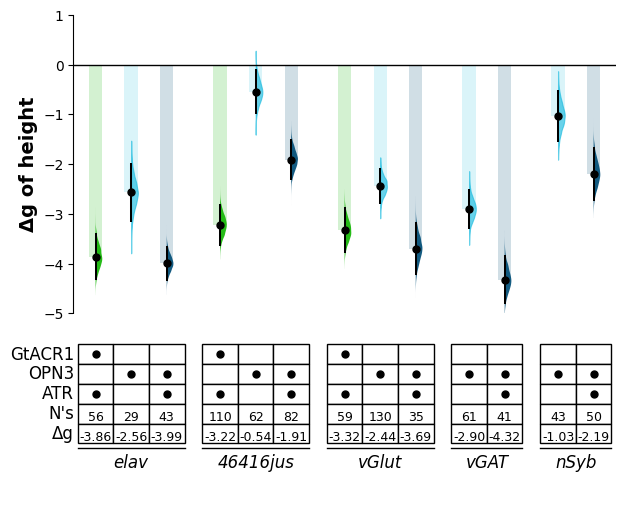

In [9]:
# Generate paired phase plots with TABLE format
lstnamings = ['height']  #height or speed

files_wt = [f'elav x ACR [ATR] allstats_DARK_FULL.csv', f'elav x eOPN3 allstats_DARK_FULL.csv',   f'elav x eOPN3 [ATR] allstats_DARK_FULL.csv', 
              f'46416jus x ACR [ATR] allstats_DARK_FULL.csv', f'46416jus x eOPN3 allstats_DARK_FULL.csv',f'46416jus x eOPN3 [ATR] allstats_DARK_FULL.csv',
                f'vGlut x ACR [ATR] allstats_DARK_FULL.csv', f'vGlut x eOPN3 allstats_DARK_FULL.csv', f'vGlut x eOPN3 [ATR] allstats_DARK_FULL.csv',
                f'vGAT x eOPN3 allstats_DARK_FULL.csv', f'vGAT x eOPN3 [ATR] allstats_DARK_FULL.csv',
              f'nSyb x eOPN3 allstats_DARK_FULL.csv', f'nSyb x eOPN3 [ATR] allstats_DARK_FULL.csv']

files_full = [f.replace('.csv', '_wtcomparison.csv') for f in files_wt]

for n in lstnamings:
    dfmn_full, dfsmd_full = pergenotypeplotting_deltag(openPath, files_full, n)

    g_table = forestplot_single_phase_table(
        dfmn_full.replace("ACR", "GtACR1", regex=True), 
        dfsmd_full.replace("ACR", "GtACR1", regex=True), 
        "GtACR1", "OPN3", figsize=(7,6), ylim=(-5, 1.0), ratio=[0.6, 0.4],
        gridkey_fontsize=9, ytick_fontsize= 10, ylabel_fontsize= 14, xlabel_fontsize= 12, gridkey_ylabel_fontsize= 12, markersize=5)
    
    mpl.rcParams['svg.fonttype'] = 'none' 
    plt.show()

## Supplementary Figure 2

In [12]:
genotypes = ['elav x eOPN3', 'elav x PdCO', 
                'OK371 x eOPN3', 'OK371 x PdCO',
              'nSyb x eOPN3', 'nSyb x PdCO']

processedPath = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\2. Processed\\"

compiled_files = [g + " allstats_DARK_FULL_wtcomparison.csv" for g in genotypes]
processed_files = [(processedPath + g + ".csv", processedPath + "w1118_" + g + ".csv") for g in genotypes]

firstcolor = '#808080'

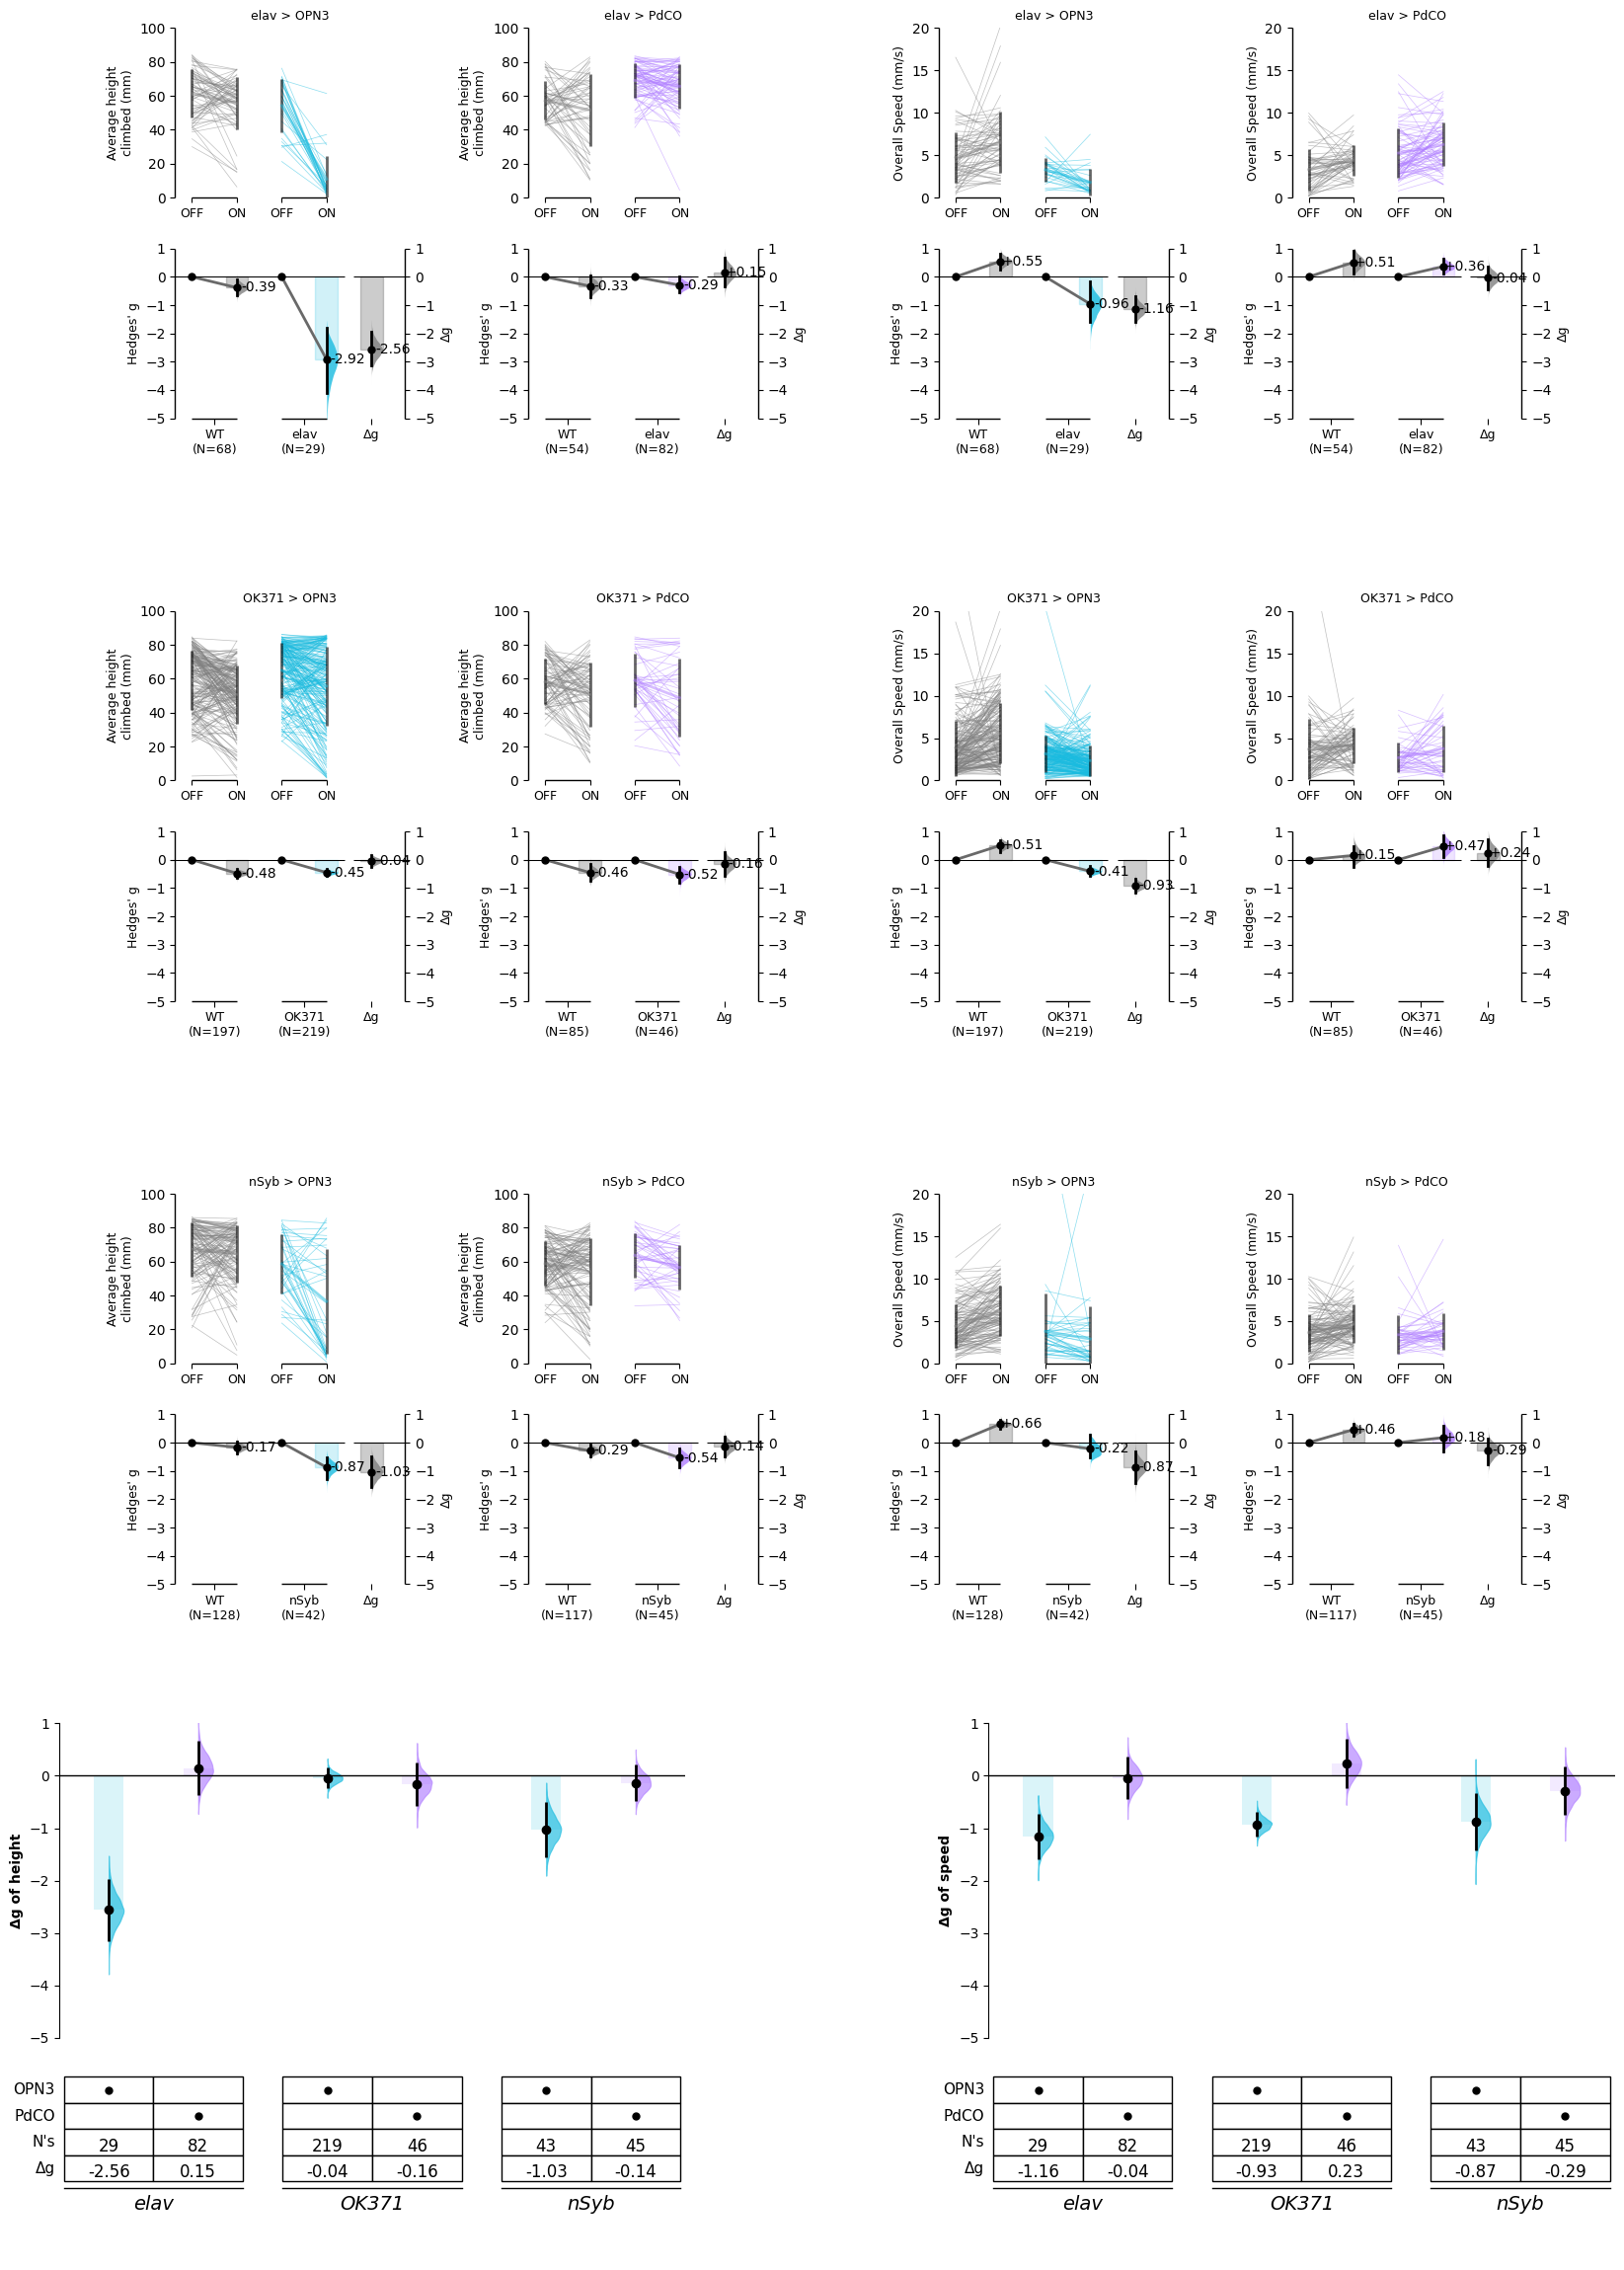

In [14]:
genotype_data = {}

for g in genotypes:
    driver = g.split(' x ')[0]
    responder = g.split(' x ')[1]
    
    expt_df = pd.read_csv(processedPath + g + ".csv")
    wt_df = pd.read_csv(processedPath + "w1118_" + g + ".csv")
    
    processed_expt = NLCLIMB.fivesecondrule(NLCLIMB.generation(expt_df.drop(expt_df.columns[[0]], axis=1), driver))
    processed_wt = NLCLIMB.fivesecondrule(NLCLIMB.generation(wt_df.drop(wt_df.columns[[0]], axis=1), "w1118"))

    height_data = NLMATH.totalheight(processed_expt, processed_wt)
    height_data.loc[height_data['Type'] == 'Expt', 'Type'] = driver
    height_data['genre'] = height_data['ExperimentState'] + " " + height_data['Type']
    height_d2 = height_data[height_data['ExperimentState'].isin(['Dark', 'Full'])].copy()
    if any(height_d2['Y'].isnull()):
        null_names = height_d2[height_d2['Y'].isnull()]['index'].tolist()
        height_d2 = height_d2[~height_d2['index'].isin(null_names)]

    height_dabest = dabest.load(
        data=height_d2, x=["ExperimentState", "Type"], y="Y",
        experiment="Type", experiment_label=['WT', driver],
        x1_level=['Dark', 'Full'], paired="baseline", id_col="index", delta2=True)

    vel_data = NLMATH.ospeed(processed_wt, processed_expt)
    vel_data.loc[vel_data['Type'] == 'Expt', 'Type'] = driver
    vel_data['genre'] = vel_data['ExperimentState'] + " " + vel_data['Type']
    vel_d2 = vel_data[vel_data['ExperimentState'].isin(['Dark', 'Full'])].copy()
    if any(vel_d2['Velocity'].isnull()):
        null_names = vel_d2[vel_d2['Velocity'].isnull()]['index'].tolist()
        vel_d2 = vel_d2[~vel_d2['index'].isin(null_names)]

    vel_dabest = dabest.load(
        data=vel_d2, x=["ExperimentState", "Type"], y="Velocity",
        experiment="Type", experiment_label=['WT', driver],
        x1_level=['Dark', 'Full'], paired="baseline", id_col="index", delta2=True)

    display_resp = responder.replace("eOPN3", "OPN3")
    resp_color, resp_no_atr, resp_has_atr = get_responder_color(g)

    n_wt = height_d2[(height_d2['Type'] == 'WT') & (height_d2['ExperimentState'] == 'Dark')]['Y'].count()
    n_driver = height_d2[(height_d2['Type'] == driver) & (height_d2['ExperimentState'] == 'Dark')]['Y'].count()

    genotype_data[g] = {
        'height_dabest': height_dabest,
        'vel_dabest': vel_dabest,
        'display_name': driver + " > " + display_resp,
        'color': resp_color if resp_has_atr else resp_no_atr,
        'n_wt': n_wt,
        'n_driver': n_driver
    }

from matplotlib.gridspec import GridSpec

n_geno = len(genotypes)
n_cols = 4
n_rows = 3  # 4 driver pairs

common_style = {'fontsize_rawxlabel': 9, 'fontsize_rawylabel': 9, 'fontsize_contrastxlabel': 9,
                'fontsize_contrastylabel': 9, 'fontsize_delta2label': 9, 'contrast_marker_size': 5}

fig = plt.figure(figsize=(4 * n_cols * 1.1, 24))
# Outer: top = 4x4 dabest grid (one driver pair per row, cols 0-1 = height, cols 2-3 = speed),
# bottom = side-by-side summary forest plots.
outer = fig.subfigures(2, 1, height_ratios=[2.4, 1.0])

general_fontsize = 12
gridkey_fontsize = 14

plot_width = 2
gap_within = 0.5   # gap between the two genotypes within a metric
gap_between = 1.0  # wider gap between the height block and the speed block
# Column structure: [plot, gap_within, plot, gap_between, plot, gap_within, plot]
widths_row = [plot_width, gap_within, plot_width, gap_between, plot_width, gap_within, plot_width]
plot_col_indices = [0, 2, 4, 6]  # indices in widths_row that hold actual plot columns

dabest_rows = outer[0].subfigures(n_rows, 1, hspace=0.15)
if n_rows == 1:
    dabest_rows = [dabest_rows]

# Build a 4x4 axes grid
axes_grid = []
for r in range(n_rows):
    gs = GridSpec(1, len(widths_row), width_ratios=widths_row, figure=dabest_rows[r])
    axes_grid.append([dabest_rows[r].add_subplot(gs[0, plot_col_indices[c]]) for c in range(n_cols)])

# For each row r: cols 0-1 plot HEIGHT for genotypes[r*2:r*2+2],
# cols 2-3 plot SPEED for the same pair.
for r in range(n_rows):
    pair = genotypes[r * 2:r * 2 + 2]
    for c in range(n_cols):
        g = pair[c % 2]
        metric = 'height' if c < 2 else 'speed'
        gd = genotype_data[g]
        driver = g.split(' x ')[0]
        ax = axes_grid[r][c]

        if metric == 'height':
            gd['height_dabest'].hedges_g.plot(
                raw_label="Average height\nclimbed (mm)",
                contrast_label="Hedges' g", delta2_label="Δg",
                raw_ylim=(0, 100), contrast_ylim=(-5, 1),
                custom_palette=[firstcolor, gd['color']],
                slopegraph_kwargs={'linewidth': 0.5},
                ax=ax, **common_style)
        else:
            gd['vel_dabest'].hedges_g.plot(
                raw_label=f"Overall Speed (mm/s)",
                contrast_label="Hedges' g", delta2_label="Δg",
                raw_ylim=(0, 20), contrast_ylim=(-5, 1),
                custom_palette=[firstcolor, gd['color']],
                slopegraph_kwargs={'linewidth': 0.5},
                ax=ax, **common_style)

        recolor_delta2(ax, firstcolor, gd['color'])
        ax.get_legend().remove()
        ax.set_title(gd['display_name'], fontsize=9)
        ax.set_xticks([0, 1, 2, 3])
        ax.set_xticklabels(['OFF', 'ON', 'OFF', 'ON'], fontsize=9)
        contrast_ax = ax.contrast_axes
        contrast_ax.set_xticks([0.5, 2.5, 4])
        contrast_ax.set_xticklabels([f'WT\n(N={gd["n_wt"]})', f'{driver}\n(N={gd["n_driver"]})', 'Δg'], fontsize=9)
        contrast_ax.spines['bottom'].set_visible(True)
        contrast_ax.tick_params(axis='x', length=4, direction='out')

# --- Bottom row: summary HEIGHT and SPEED forest plots side by side ---
bottom = outer[1].subfigures(1, 2, wspace=0.15)

# Summary HEIGHT forest plot (left)
dfmn_height, dfsmd_height = pergenotypeplotting_deltag(openPath, compiled_files, 'height')
dfmn_height = dfmn_height.replace("ACR", "GtACR1", regex=True)
dfsmd_height = dfsmd_height.replace("ACR", "GtACR1", regex=True)

matched_crosses_h = [(c, c.replace('_DARK_FULL', '').replace('_DARK_RECOVERY', ''))
                     for c in dfsmd_height['cross'].unique()]
positions_h, driver_groups_fp_h, cell_widths_h = calculate_grouped_positions(matched_crosses_h, 1.8, 0.8)
_, responders_base_h, has_atr_h, unique_responders_h = parse_responders_with_atr(matched_crosses_h)

ax_main_h, ax_table_h = bottom[0].subplots(2, 1, height_ratios=[6, 4], gridspec_kw={'hspace': 0.05})

for i, (cross_full, _) in enumerate(matched_crosses_h):
    pos = positions_h[i]
    full_data = dfmn_height[dfmn_height['Cross'] == cross_full]['bootstrap']
    full_mean = dfsmd_height[dfsmd_height['cross'] == cross_full]['mean'].iloc[0]
    full_err = dfsmd_height[dfsmd_height['cross'] == cross_full]['err'].iloc[0]
    resp_color, resp_no_atr, resp_has_atr = get_responder_color(cross_full)
    is_ts_er = 'ts-er' in cross_full.lower()
    parts = ax_main_h.violinplot([full_data], positions=[pos], widths=0.6, showmeans=False, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        if resp_has_atr:
            pc.set_facecolor(resp_color); pc.set_alpha(0.95); pc.set_edgecolor('none')
        elif is_ts_er:
            pc.set_facecolor(resp_no_atr); pc.set_alpha(0.85); pc.set_edgecolor('none')
        else:
            pc.set_facecolor(resp_no_atr); pc.set_alpha(0.65); pc.set_edgecolor(resp_no_atr); pc.set_linewidth(0.8)
        pc.get_paths()[0].vertices[:, 0] = np.maximum(pc.get_paths()[0].vertices[:, 0], pos)
        half_w = pc.get_paths()[0].vertices[:, 0].max() - pos
    bar_color = resp_color if resp_has_atr else resp_no_atr
    bar_alpha_base = 0.75 if resp_has_atr else (0.85 if is_ts_er else 0.65)
    ax_main_h.bar(pos, full_mean, width=half_w * 2, align='center', color=bar_color, alpha=bar_alpha_base * 0.25, edgecolor='none')
    ax_main_h.errorbar(pos, full_mean, yerr=full_err, fmt='o', color='black', markersize=6, capsize=0, elinewidth=2)

ax_main_h.set_ylabel("Δg of height", fontweight='bold', fontsize=10)
format_main_axes(ax_main_h, positions_h, (-5, 1.0), 10)

total_table_rows_h = len(unique_responders_h) + 2
n_row_idx_h = len(unique_responders_h)
dg_row_idx_h = total_table_rows_h - 1
cell_height_h = 0.50 / total_table_rows_h
row_y_positions_h = [0.75 - (r * cell_height_h) for r in range(total_table_rows_h)]

ax_table_h.set_xlim(min(positions_h) - 1, max(positions_h) + 1)
ax_table_h.set_ylim(0, 1)

draw_table_grid(ax_table_h, positions_h, row_y_positions_h, cell_widths_h, cell_height_h, total_table_rows_h)
place_table_dots_and_n(ax_table_h, positions_h, matched_crosses_h, responders_base_h, has_atr_h, unique_responders_h,
                       row_y_positions_h[:n_row_idx_h + 1], cell_height_h, dfsmd_height, 5, general_fontsize)

for i, (cross_full, _) in enumerate(matched_crosses_h):
    full_mean = dfsmd_height[dfsmd_height['cross'] == cross_full]['mean'].iloc[0]
    ax_table_h.text(positions_h[i], row_y_positions_h[dg_row_idx_h] + (cell_height_h * 0.35), f'{full_mean:.2f}',
                    ha='center', va='center', fontsize=general_fontsize, color='black')

max_cw_h = max(cell_widths_h)
label_x_h = min(positions_h) - max_cw_h * 0.6
for row_idx, resp in enumerate(unique_responders_h):
    ax_table_h.text(label_x_h, row_y_positions_h[row_idx] + (cell_height_h * 0.5), resp, ha='right', va='center', fontsize=11)
ax_table_h.text(label_x_h, row_y_positions_h[n_row_idx_h] + (cell_height_h * 0.5), "N's", ha='right', va='center', fontsize=11)
ax_table_h.text(label_x_h, row_y_positions_h[dg_row_idx_h] + (cell_height_h * 0.5), 'Δg', ha='right', va='center', fontsize=11)

for drv, indices in driver_groups_fp_h.items():
    if indices:
        x_pos = [positions_h[j] for j in indices]
        widths_fp = [cell_widths_h[j] for j in indices]
        y_pos = row_y_positions_h[dg_row_idx_h] - (cell_height_h * 0.25)
        ax_table_h.plot([min(x_pos) - widths_fp[0]/2, max(x_pos) + widths_fp[-1]/2], [y_pos, y_pos], 'k-', linewidth=1)
        ax_table_h.text(np.mean(x_pos), y_pos - (cell_height_h * 0.25), drv, ha='center', va='top', fontsize=gridkey_fontsize, style='italic')

cleanup_table_axes(ax_table_h)

# Summary SPEED forest plot (right)
dfmn_speed, dfsmd_speed = pergenotypeplotting_deltag(openPath, compiled_files, 'speed')
dfmn_speed = dfmn_speed.replace("ACR", "GtACR1", regex=True)
dfsmd_speed = dfsmd_speed.replace("ACR", "GtACR1", regex=True)

matched_crosses = [(c, c.replace('_DARK_FULL', '').replace('_DARK_RECOVERY', ''))
                   for c in dfsmd_speed['cross'].unique()]
positions, driver_groups_fp, cell_widths = calculate_grouped_positions(matched_crosses, 1.8, 0.8)
_, responders_base, has_atr, unique_responders = parse_responders_with_atr(matched_crosses)

ax_main, ax_table = bottom[1].subplots(2, 1, height_ratios=[6, 4], gridspec_kw={'hspace': 0.05})

for i, (cross_full, _) in enumerate(matched_crosses):
    pos = positions[i]
    full_data = dfmn_speed[dfmn_speed['Cross'] == cross_full]['bootstrap']
    full_mean = dfsmd_speed[dfsmd_speed['cross'] == cross_full]['mean'].iloc[0]
    full_err = dfsmd_speed[dfsmd_speed['cross'] == cross_full]['err'].iloc[0]
    resp_color, resp_no_atr, resp_has_atr = get_responder_color(cross_full)
    is_ts_er = 'ts-er' in cross_full.lower()
    parts = ax_main.violinplot([full_data], positions=[pos], widths=0.6, showmeans=False, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        if resp_has_atr:
            pc.set_facecolor(resp_color); pc.set_alpha(0.95); pc.set_edgecolor('none')
        elif is_ts_er:
            pc.set_facecolor(resp_no_atr); pc.set_alpha(0.85); pc.set_edgecolor('none')
        else:
            pc.set_facecolor(resp_no_atr); pc.set_alpha(0.65); pc.set_edgecolor(resp_no_atr); pc.set_linewidth(0.8)
        pc.get_paths()[0].vertices[:, 0] = np.maximum(pc.get_paths()[0].vertices[:, 0], pos)
        half_w = pc.get_paths()[0].vertices[:, 0].max() - pos
    bar_color = resp_color if resp_has_atr else resp_no_atr
    bar_alpha_base = 0.75 if resp_has_atr else (0.85 if is_ts_er else 0.65)
    ax_main.bar(pos, full_mean, width=half_w * 2, align='center', color=bar_color, alpha=bar_alpha_base * 0.25, edgecolor='none')
    ax_main.errorbar(pos, full_mean, yerr=full_err, fmt='o', color='black', markersize=6, capsize=0, elinewidth=2)

ax_main.set_ylabel("Δg of speed", fontweight='bold', fontsize=10)
format_main_axes(ax_main, positions, (-5, 1.0), 10)

total_table_rows = len(unique_responders) + 2
n_row_idx = len(unique_responders)
dg_row_idx = total_table_rows - 1
cell_height = 0.50 / total_table_rows
row_y_positions = [0.75 - (r * cell_height) for r in range(total_table_rows)]

ax_table.set_xlim(min(positions) - 1, max(positions) + 1)
ax_table.set_ylim(0, 1)

draw_table_grid(ax_table, positions, row_y_positions, cell_widths, cell_height, total_table_rows)
place_table_dots_and_n(ax_table, positions, matched_crosses, responders_base, has_atr, unique_responders,
                       row_y_positions[:n_row_idx + 1], cell_height, dfsmd_speed, 5, general_fontsize)

for i, (cross_full, _) in enumerate(matched_crosses):
    full_mean = dfsmd_speed[dfsmd_speed['cross'] == cross_full]['mean'].iloc[0]
    ax_table.text(positions[i], row_y_positions[dg_row_idx] + (cell_height * 0.35), f'{full_mean:.2f}',
                  ha='center', va='center', fontsize=general_fontsize, color='black')

max_cw = max(cell_widths)
label_x = min(positions) - max_cw * 0.6
for row_idx, resp in enumerate(unique_responders):
    ax_table.text(label_x, row_y_positions[row_idx] + (cell_height * 0.5), resp, ha='right', va='center', fontsize=11)
ax_table.text(label_x, row_y_positions[n_row_idx] + (cell_height * 0.5), "N's", ha='right', va='center', fontsize=11)
ax_table.text(label_x, row_y_positions[dg_row_idx] + (cell_height * 0.5), 'Δg', ha='right', va='center', fontsize=11)

for drv, indices in driver_groups_fp.items():
    if indices:
        x_pos = [positions[j] for j in indices]
        widths_fp = [cell_widths[j] for j in indices]
        y_pos = row_y_positions[dg_row_idx] - (cell_height * 0.25)
        ax_table.plot([min(x_pos) - widths_fp[0]/2, max(x_pos) + widths_fp[-1]/2], [y_pos, y_pos], 'k-', linewidth=1)
        ax_table.text(np.mean(x_pos), y_pos - (cell_height * 0.25), drv, ha='center', va='top', fontsize=gridkey_fontsize, style='italic')

cleanup_table_axes(ax_table)

mpl.rcParams['svg.fonttype'] = 'none'
plt.show()


## Supplementary Figure 3

In [10]:
genotypes = ['elav x eOPN3', 'elav x eOPN3-TS-ER', 
              '46416jus x eOPN3','46416jus x eOPN3-TS-ER',
                'vGAT x eOPN3', 'vGAT x eOPN3-TS-ER',
              'nSyb x eOPN3', 'nSyb x eOPN3-TS-ER']

processedPath = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\2. Processed\\"

compiled_files = [g + " allstats_DARK_FULL_wtcomparison.csv" for g in genotypes]
processed_files = [(processedPath + g + ".csv", processedPath + "w1118_" + g + ".csv") for g in genotypes]

firstcolor = '#808080'

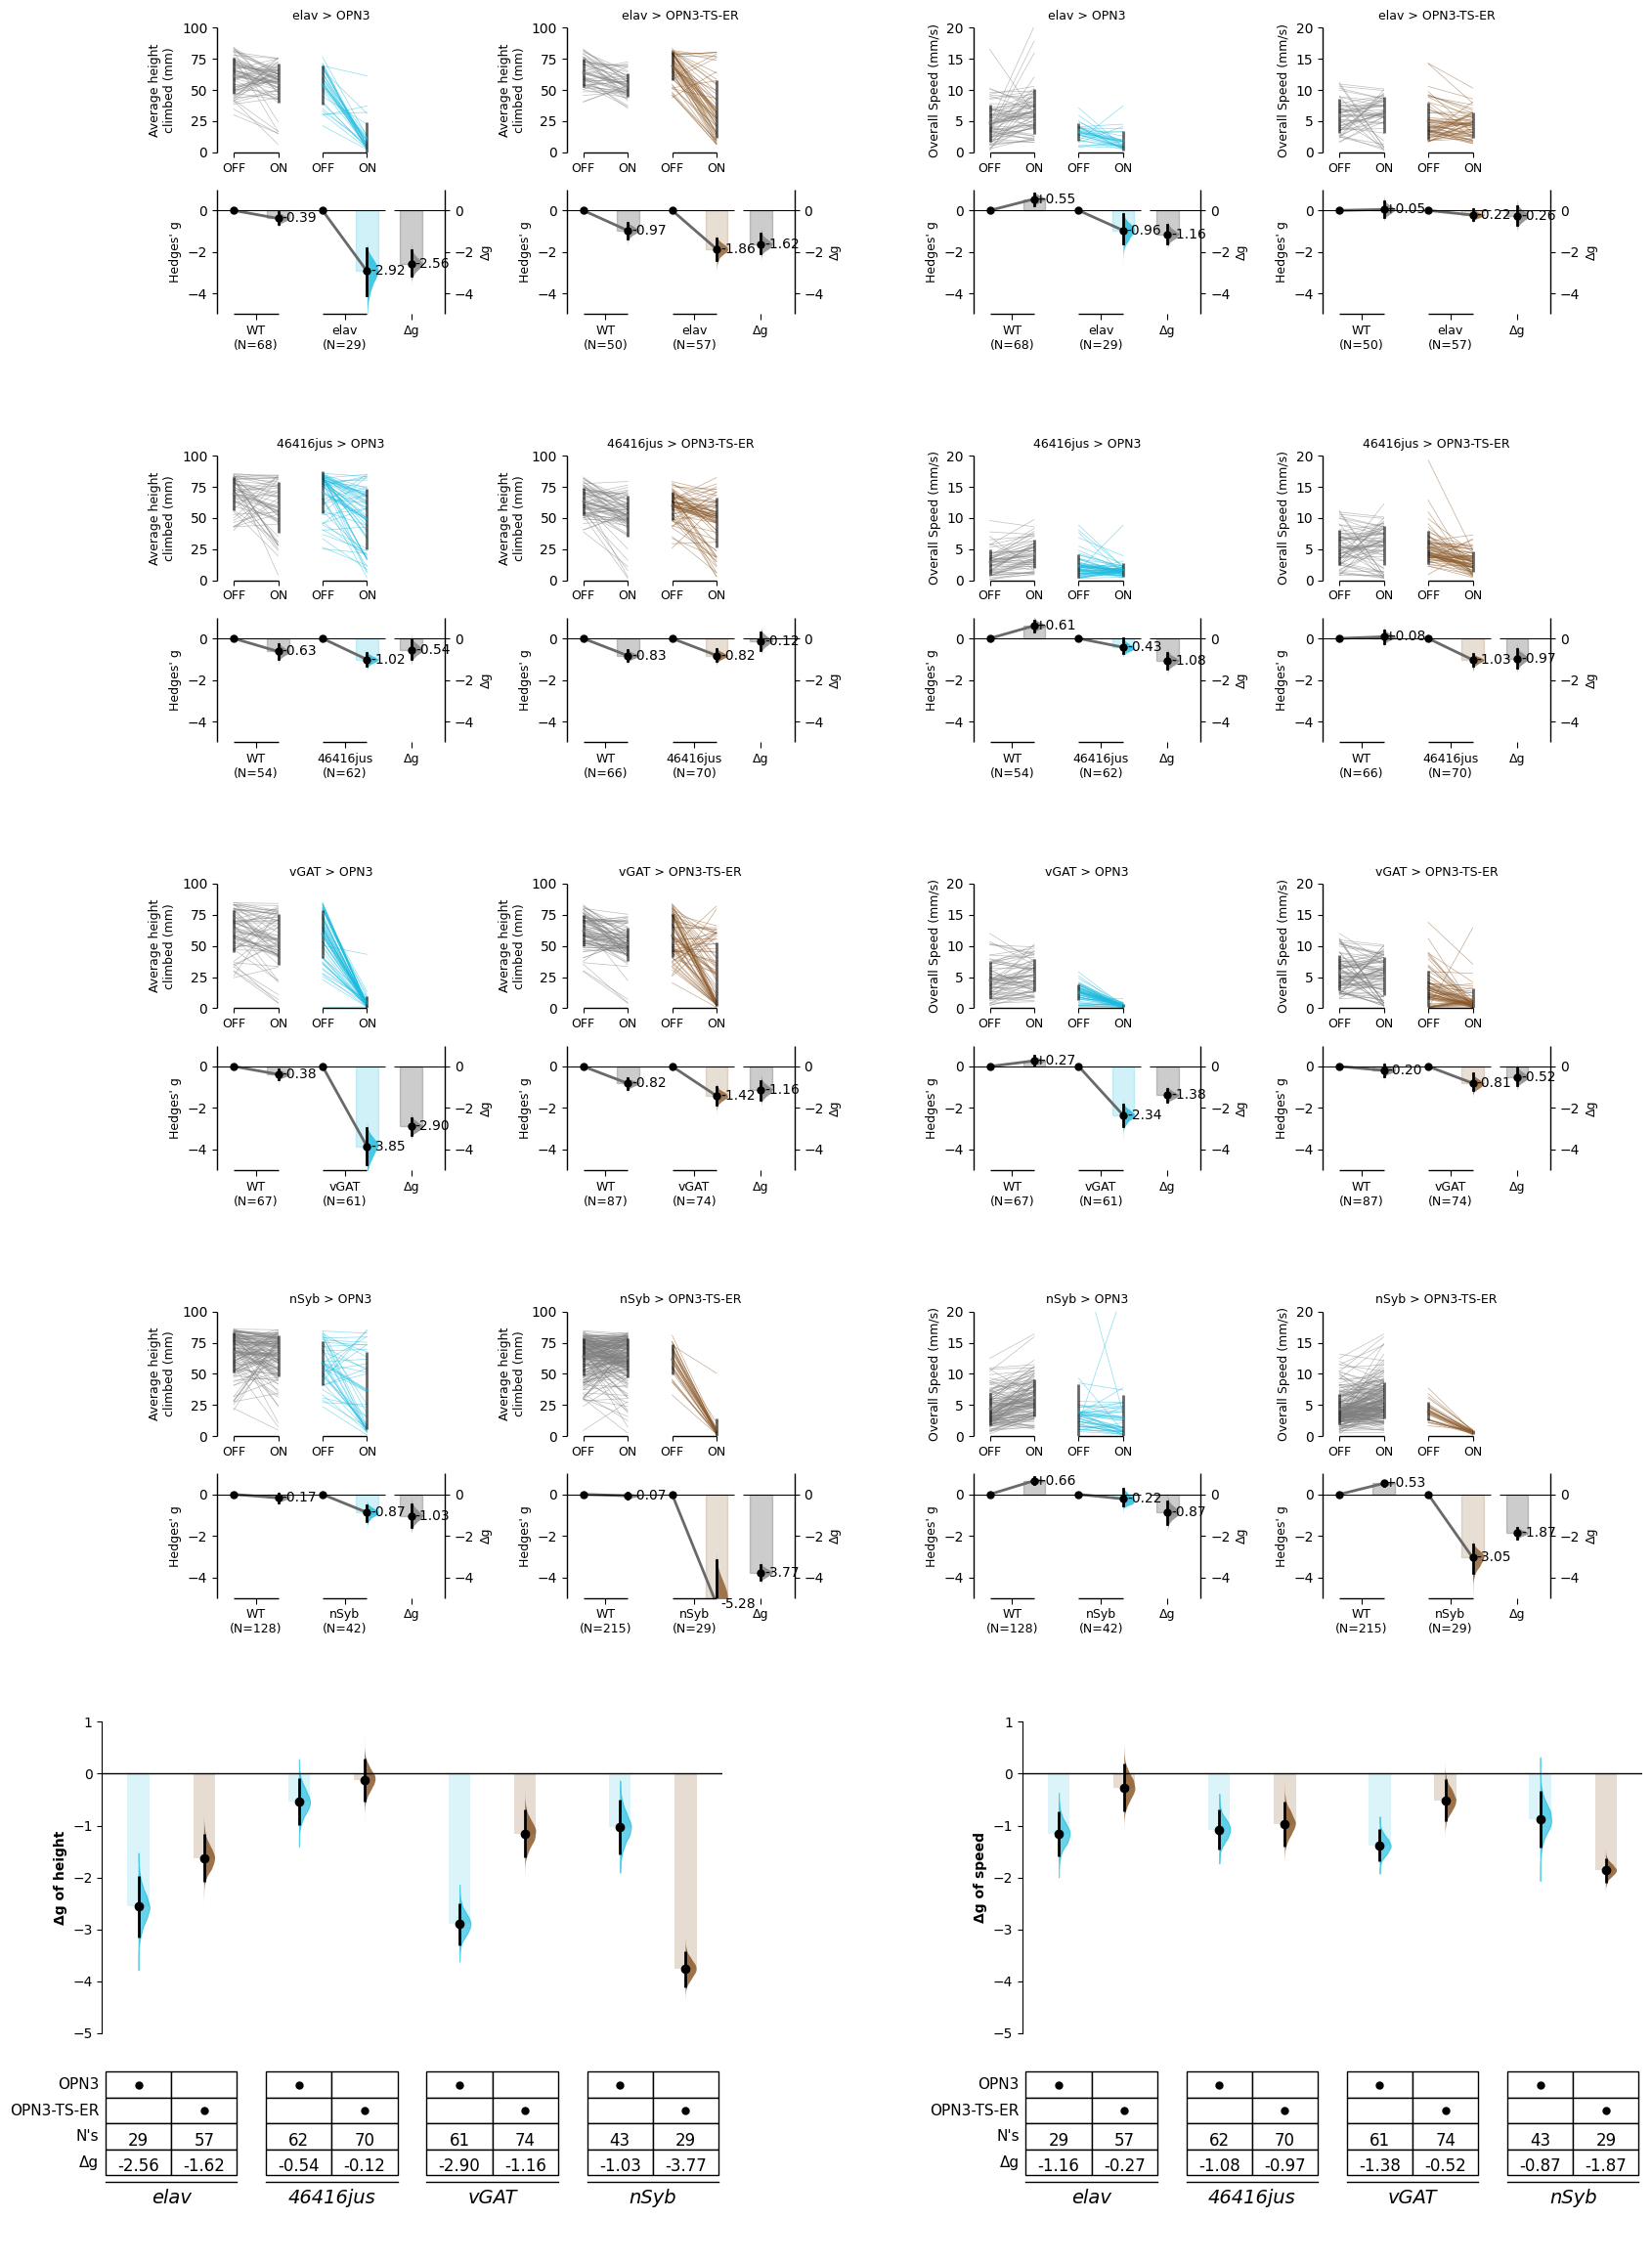

In [11]:
genotype_data = {}

for g in genotypes:
    driver = g.split(' x ')[0]
    responder = g.split(' x ')[1]
    
    expt_df = pd.read_csv(processedPath + g + ".csv")
    wt_df = pd.read_csv(processedPath + "w1118_" + g + ".csv")
    
    processed_expt = NLCLIMB.fivesecondrule(NLCLIMB.generation(expt_df.drop(expt_df.columns[[0]], axis=1), driver))
    processed_wt = NLCLIMB.fivesecondrule(NLCLIMB.generation(wt_df.drop(wt_df.columns[[0]], axis=1), "w1118"))

    height_data = NLMATH.totalheight(processed_expt, processed_wt)
    height_data.loc[height_data['Type'] == 'Expt', 'Type'] = driver
    height_data['genre'] = height_data['ExperimentState'] + " " + height_data['Type']
    height_d2 = height_data[height_data['ExperimentState'].isin(['Dark', 'Full'])].copy()
    if any(height_d2['Y'].isnull()):
        null_names = height_d2[height_d2['Y'].isnull()]['index'].tolist()
        height_d2 = height_d2[~height_d2['index'].isin(null_names)]

    height_dabest = dabest.load(
        data=height_d2, x=["ExperimentState", "Type"], y="Y",
        experiment="Type", experiment_label=['WT', driver],
        x1_level=['Dark', 'Full'], paired="baseline", id_col="index", delta2=True)

    vel_data = NLMATH.ospeed(processed_wt, processed_expt)
    vel_data.loc[vel_data['Type'] == 'Expt', 'Type'] = driver
    vel_data['genre'] = vel_data['ExperimentState'] + " " + vel_data['Type']
    vel_d2 = vel_data[vel_data['ExperimentState'].isin(['Dark', 'Full'])].copy()
    if any(vel_d2['Velocity'].isnull()):
        null_names = vel_d2[vel_d2['Velocity'].isnull()]['index'].tolist()
        vel_d2 = vel_d2[~vel_d2['index'].isin(null_names)]

    vel_dabest = dabest.load(
        data=vel_d2, x=["ExperimentState", "Type"], y="Velocity",
        experiment="Type", experiment_label=['WT', driver],
        x1_level=['Dark', 'Full'], paired="baseline", id_col="index", delta2=True)

    display_resp = responder.replace("eOPN3", "OPN3")
    resp_color, resp_no_atr, resp_has_atr = get_responder_color(g)

    n_wt = height_d2[(height_d2['Type'] == 'WT') & (height_d2['ExperimentState'] == 'Dark')]['Y'].count()
    n_driver = height_d2[(height_d2['Type'] == driver) & (height_d2['ExperimentState'] == 'Dark')]['Y'].count()

    genotype_data[g] = {
        'height_dabest': height_dabest,
        'vel_dabest': vel_dabest,
        'display_name': driver + " > " + display_resp,
        'color': resp_color if resp_has_atr else resp_no_atr,
        'n_wt': n_wt,
        'n_driver': n_driver
    }

from matplotlib.gridspec import GridSpec

n_geno = len(genotypes)
n_cols = 4
n_rows = 4  # 4 driver pairs

common_style = {'fontsize_rawxlabel': 9, 'fontsize_rawylabel': 9, 'fontsize_contrastxlabel': 9,
                'fontsize_contrastylabel': 9, 'fontsize_delta2label': 9, 'contrast_marker_size': 5}

fig = plt.figure(figsize=(4 * n_cols * 1.1, 24))
# Outer: top = 4x4 dabest grid (one driver pair per row, cols 0-1 = height, cols 2-3 = speed),
# bottom = side-by-side summary forest plots.
outer = fig.subfigures(2, 1, height_ratios=[2.4, 1.0])

general_fontsize = 12
gridkey_fontsize = 14

plot_width = 2
gap_within = 0.5   # gap between the two genotypes within a metric
gap_between = 1.0  # wider gap between the height block and the speed block
# Column structure: [plot, gap_within, plot, gap_between, plot, gap_within, plot]
widths_row = [plot_width, gap_within, plot_width, gap_between, plot_width, gap_within, plot_width]
plot_col_indices = [0, 2, 4, 6]  # indices in widths_row that hold actual plot columns

dabest_rows = outer[0].subfigures(n_rows, 1, hspace=0.15)
if n_rows == 1:
    dabest_rows = [dabest_rows]

# Build a 4x4 axes grid
axes_grid = []
for r in range(n_rows):
    gs = GridSpec(1, len(widths_row), width_ratios=widths_row, figure=dabest_rows[r])
    axes_grid.append([dabest_rows[r].add_subplot(gs[0, plot_col_indices[c]]) for c in range(n_cols)])

# For each row r: cols 0-1 plot HEIGHT for genotypes[r*2:r*2+2],
# cols 2-3 plot SPEED for the same pair.
for r in range(n_rows):
    pair = genotypes[r * 2:r * 2 + 2]
    for c in range(n_cols):
        g = pair[c % 2]
        metric = 'height' if c < 2 else 'speed'
        gd = genotype_data[g]
        driver = g.split(' x ')[0]
        ax = axes_grid[r][c]

        if metric == 'height':
            gd['height_dabest'].hedges_g.plot(
                raw_label="Average height\nclimbed (mm)",
                contrast_label="Hedges' g", delta2_label="Δg",
                raw_ylim=(0, 100), contrast_ylim=(-5, 1),
                custom_palette=[firstcolor, gd['color']],
                slopegraph_kwargs={'linewidth': 0.5},
                ax=ax, **common_style)
        else:
            gd['vel_dabest'].hedges_g.plot(
                raw_label=f"Overall Speed (mm/s)",
                contrast_label="Hedges' g", delta2_label="Δg",
                raw_ylim=(0, 20), contrast_ylim=(-5, 1),
                custom_palette=[firstcolor, gd['color']],
                slopegraph_kwargs={'linewidth': 0.5},
                ax=ax, **common_style)

        recolor_delta2(ax, firstcolor, gd['color'])
        ax.get_legend().remove()
        ax.set_title(gd['display_name'], fontsize=9)
        ax.set_xticks([0, 1, 2, 3])
        ax.set_xticklabels(['OFF', 'ON', 'OFF', 'ON'], fontsize=9)
        contrast_ax = ax.contrast_axes
        contrast_ax.set_xticks([0.5, 2.5, 4])
        contrast_ax.set_xticklabels([f'WT\n(N={gd["n_wt"]})', f'{driver}\n(N={gd["n_driver"]})', 'Δg'], fontsize=9)
        contrast_ax.spines['bottom'].set_visible(True)
        contrast_ax.tick_params(axis='x', length=4, direction='out')

# --- Bottom row: summary HEIGHT and SPEED forest plots side by side ---
bottom = outer[1].subfigures(1, 2, wspace=0.15)

# Summary HEIGHT forest plot (left)
dfmn_height, dfsmd_height = pergenotypeplotting_deltag(openPath, compiled_files, 'height')
dfmn_height = dfmn_height.replace("ACR", "GtACR1", regex=True)
dfsmd_height = dfsmd_height.replace("ACR", "GtACR1", regex=True)

matched_crosses_h = [(c, c.replace('_DARK_FULL', '').replace('_DARK_RECOVERY', ''))
                     for c in dfsmd_height['cross'].unique()]
positions_h, driver_groups_fp_h, cell_widths_h = calculate_grouped_positions(matched_crosses_h, 1.8, 0.8)
_, responders_base_h, has_atr_h, unique_responders_h = parse_responders_with_atr(matched_crosses_h)

ax_main_h, ax_table_h = bottom[0].subplots(2, 1, height_ratios=[6, 4], gridspec_kw={'hspace': 0.05})

for i, (cross_full, _) in enumerate(matched_crosses_h):
    pos = positions_h[i]
    full_data = dfmn_height[dfmn_height['Cross'] == cross_full]['bootstrap']
    full_mean = dfsmd_height[dfsmd_height['cross'] == cross_full]['mean'].iloc[0]
    full_err = dfsmd_height[dfsmd_height['cross'] == cross_full]['err'].iloc[0]
    resp_color, resp_no_atr, resp_has_atr = get_responder_color(cross_full)
    is_ts_er = 'ts-er' in cross_full.lower()
    parts = ax_main_h.violinplot([full_data], positions=[pos], widths=0.6, showmeans=False, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        if resp_has_atr:
            pc.set_facecolor(resp_color); pc.set_alpha(0.95); pc.set_edgecolor('none')
        elif is_ts_er:
            pc.set_facecolor(resp_no_atr); pc.set_alpha(0.85); pc.set_edgecolor('none')
        else:
            pc.set_facecolor(resp_no_atr); pc.set_alpha(0.65); pc.set_edgecolor(resp_no_atr); pc.set_linewidth(0.8)
        pc.get_paths()[0].vertices[:, 0] = np.maximum(pc.get_paths()[0].vertices[:, 0], pos)
        half_w = pc.get_paths()[0].vertices[:, 0].max() - pos
    bar_color = resp_color if resp_has_atr else resp_no_atr
    bar_alpha_base = 0.75 if resp_has_atr else (0.85 if is_ts_er else 0.65)
    ax_main_h.bar(pos, full_mean, width=half_w * 2, align='center', color=bar_color, alpha=bar_alpha_base * 0.25, edgecolor='none')
    ax_main_h.errorbar(pos, full_mean, yerr=full_err, fmt='o', color='black', markersize=6, capsize=0, elinewidth=2)

ax_main_h.set_ylabel("Δg of height", fontweight='bold', fontsize=10)
format_main_axes(ax_main_h, positions_h, (-5, 1.0), 10)

total_table_rows_h = len(unique_responders_h) + 2
n_row_idx_h = len(unique_responders_h)
dg_row_idx_h = total_table_rows_h - 1
cell_height_h = 0.50 / total_table_rows_h
row_y_positions_h = [0.75 - (r * cell_height_h) for r in range(total_table_rows_h)]

ax_table_h.set_xlim(min(positions_h) - 1, max(positions_h) + 1)
ax_table_h.set_ylim(0, 1)

draw_table_grid(ax_table_h, positions_h, row_y_positions_h, cell_widths_h, cell_height_h, total_table_rows_h)
place_table_dots_and_n(ax_table_h, positions_h, matched_crosses_h, responders_base_h, has_atr_h, unique_responders_h,
                       row_y_positions_h[:n_row_idx_h + 1], cell_height_h, dfsmd_height, 5, general_fontsize)

for i, (cross_full, _) in enumerate(matched_crosses_h):
    full_mean = dfsmd_height[dfsmd_height['cross'] == cross_full]['mean'].iloc[0]
    ax_table_h.text(positions_h[i], row_y_positions_h[dg_row_idx_h] + (cell_height_h * 0.35), f'{full_mean:.2f}',
                    ha='center', va='center', fontsize=general_fontsize, color='black')

max_cw_h = max(cell_widths_h)
label_x_h = min(positions_h) - max_cw_h * 0.6
for row_idx, resp in enumerate(unique_responders_h):
    ax_table_h.text(label_x_h, row_y_positions_h[row_idx] + (cell_height_h * 0.5), resp, ha='right', va='center', fontsize=11)
ax_table_h.text(label_x_h, row_y_positions_h[n_row_idx_h] + (cell_height_h * 0.5), "N's", ha='right', va='center', fontsize=11)
ax_table_h.text(label_x_h, row_y_positions_h[dg_row_idx_h] + (cell_height_h * 0.5), 'Δg', ha='right', va='center', fontsize=11)

for drv, indices in driver_groups_fp_h.items():
    if indices:
        x_pos = [positions_h[j] for j in indices]
        widths_fp = [cell_widths_h[j] for j in indices]
        y_pos = row_y_positions_h[dg_row_idx_h] - (cell_height_h * 0.25)
        ax_table_h.plot([min(x_pos) - widths_fp[0]/2, max(x_pos) + widths_fp[-1]/2], [y_pos, y_pos], 'k-', linewidth=1)
        ax_table_h.text(np.mean(x_pos), y_pos - (cell_height_h * 0.25), drv, ha='center', va='top', fontsize=gridkey_fontsize, style='italic')

cleanup_table_axes(ax_table_h)

# Summary SPEED forest plot (right)
dfmn_speed, dfsmd_speed = pergenotypeplotting_deltag(openPath, compiled_files, 'speed')
dfmn_speed = dfmn_speed.replace("ACR", "GtACR1", regex=True)
dfsmd_speed = dfsmd_speed.replace("ACR", "GtACR1", regex=True)

matched_crosses = [(c, c.replace('_DARK_FULL', '').replace('_DARK_RECOVERY', ''))
                   for c in dfsmd_speed['cross'].unique()]
positions, driver_groups_fp, cell_widths = calculate_grouped_positions(matched_crosses, 1.8, 0.8)
_, responders_base, has_atr, unique_responders = parse_responders_with_atr(matched_crosses)

ax_main, ax_table = bottom[1].subplots(2, 1, height_ratios=[6, 4], gridspec_kw={'hspace': 0.05})

for i, (cross_full, _) in enumerate(matched_crosses):
    pos = positions[i]
    full_data = dfmn_speed[dfmn_speed['Cross'] == cross_full]['bootstrap']
    full_mean = dfsmd_speed[dfsmd_speed['cross'] == cross_full]['mean'].iloc[0]
    full_err = dfsmd_speed[dfsmd_speed['cross'] == cross_full]['err'].iloc[0]
    resp_color, resp_no_atr, resp_has_atr = get_responder_color(cross_full)
    is_ts_er = 'ts-er' in cross_full.lower()
    parts = ax_main.violinplot([full_data], positions=[pos], widths=0.6, showmeans=False, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        if resp_has_atr:
            pc.set_facecolor(resp_color); pc.set_alpha(0.95); pc.set_edgecolor('none')
        elif is_ts_er:
            pc.set_facecolor(resp_no_atr); pc.set_alpha(0.85); pc.set_edgecolor('none')
        else:
            pc.set_facecolor(resp_no_atr); pc.set_alpha(0.65); pc.set_edgecolor(resp_no_atr); pc.set_linewidth(0.8)
        pc.get_paths()[0].vertices[:, 0] = np.maximum(pc.get_paths()[0].vertices[:, 0], pos)
        half_w = pc.get_paths()[0].vertices[:, 0].max() - pos
    bar_color = resp_color if resp_has_atr else resp_no_atr
    bar_alpha_base = 0.75 if resp_has_atr else (0.85 if is_ts_er else 0.65)
    ax_main.bar(pos, full_mean, width=half_w * 2, align='center', color=bar_color, alpha=bar_alpha_base * 0.25, edgecolor='none')
    ax_main.errorbar(pos, full_mean, yerr=full_err, fmt='o', color='black', markersize=6, capsize=0, elinewidth=2)

ax_main.set_ylabel("Δg of speed", fontweight='bold', fontsize=10)
format_main_axes(ax_main, positions, (-5, 1.0), 10)

total_table_rows = len(unique_responders) + 2
n_row_idx = len(unique_responders)
dg_row_idx = total_table_rows - 1
cell_height = 0.50 / total_table_rows
row_y_positions = [0.75 - (r * cell_height) for r in range(total_table_rows)]

ax_table.set_xlim(min(positions) - 1, max(positions) + 1)
ax_table.set_ylim(0, 1)

draw_table_grid(ax_table, positions, row_y_positions, cell_widths, cell_height, total_table_rows)
place_table_dots_and_n(ax_table, positions, matched_crosses, responders_base, has_atr, unique_responders,
                       row_y_positions[:n_row_idx + 1], cell_height, dfsmd_speed, 5, general_fontsize)

for i, (cross_full, _) in enumerate(matched_crosses):
    full_mean = dfsmd_speed[dfsmd_speed['cross'] == cross_full]['mean'].iloc[0]
    ax_table.text(positions[i], row_y_positions[dg_row_idx] + (cell_height * 0.35), f'{full_mean:.2f}',
                  ha='center', va='center', fontsize=general_fontsize, color='black')

max_cw = max(cell_widths)
label_x = min(positions) - max_cw * 0.6
for row_idx, resp in enumerate(unique_responders):
    ax_table.text(label_x, row_y_positions[row_idx] + (cell_height * 0.5), resp, ha='right', va='center', fontsize=11)
ax_table.text(label_x, row_y_positions[n_row_idx] + (cell_height * 0.5), "N's", ha='right', va='center', fontsize=11)
ax_table.text(label_x, row_y_positions[dg_row_idx] + (cell_height * 0.5), 'Δg', ha='right', va='center', fontsize=11)

for drv, indices in driver_groups_fp.items():
    if indices:
        x_pos = [positions[j] for j in indices]
        widths_fp = [cell_widths[j] for j in indices]
        y_pos = row_y_positions[dg_row_idx] - (cell_height * 0.25)
        ax_table.plot([min(x_pos) - widths_fp[0]/2, max(x_pos) + widths_fp[-1]/2], [y_pos, y_pos], 'k-', linewidth=1)
        ax_table.text(np.mean(x_pos), y_pos - (cell_height * 0.25), drv, ha='center', va='top', fontsize=gridkey_fontsize, style='italic')

cleanup_table_axes(ax_table)

mpl.rcParams['svg.fonttype'] = 'none'
plt.show()


## Supplementary Figure 5